In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from plant_shape_analysis.data_preprocessing.process_gt_TrackPlant3D  import custom_trimmed_poisson

%load_ext autoreload
%autoreload 2

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Get GT data

We review the manual quality assesment of the dense point cloud data to only compute traits for the good leaves for now

In [2]:
base_path = Path("../data/TrackPlant3D")
qa_csv = base_path / "dense_leaves" / "dense_leaves_quality_assesment.csv"
df = pd.read_csv(qa_csv, delimiter=';')
df.head()

,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN
1,1,1,1_maize_control_plant1_D00_leaf2_dense,maize,control,1,0,2,bad,large holes
2,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN
3,3,1,2_maize_control_plant1_D01_leaf2_dense,maize,control,1,1,2,bad,poor segmentation
4,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN


In [3]:
good_leaves = df.loc[df['quality'] == 'good'].reset_index(drop=True)
good_leaves

,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN
1,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN
2,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN
3,7,0,4_maize_control_plant1_D03_leaf1_dense,maize,control,1,3,1,good,NaN
4,8,1,4_maize_control_plant1_D03_leaf2_dense,maize,control,1,3,2,good,NaN
...,...,...,...,...,...,...,...,...,...,...
88,200,32,376_tomato2_control_plant3_D06_leaf2_dense,tomato2,control,3,6,2,good,"small noise - apply SOR(nb=50,std=10) - remove..."
89,201,33,376_tomato2_control_plant3_D06_leaf3_dense,tomato2,control,3,6,3,good,"small noise - apply SOR(nb=50,std=10) - remove..."
90,205,31,377_tomato2_control_plant3_D07_leaf1_dense,tomato2,control,3,7,1,good,"small noise - apply SOR(nb=50,std=10) - remove..."
91,207,33,377_tomato2_control_plant3_D07_leaf3_dense,tomato2,control,3,7,3,good,"small noise - apply SOR(nb=50,std=10) - remove..."


In [4]:
# Load the JSON data with surface area measurements for all crops
surface_dict = {}

# Load maize data
json_path_maize = base_path / "dense_leaf_meshes" / "maize" / "processing_results.json"
with open(json_path_maize, 'r') as f:
    surface_data_maize = json.load(f)

for entry in surface_data_maize:
    filename = entry['leaf_file'].replace('.ply', '')
    surface_dict[filename] = entry['surface_area']

# Load tomato data  
json_path_tomato = base_path / "dense_leaf_meshes" / "tomato" / "processing_results.json"
with open(json_path_tomato, 'r') as f:
    surface_data_tomato = json.load(f)

for entry in surface_data_tomato:
    filename = entry['leaf_file'].replace('.ply', '')
    surface_dict[filename] = entry['surface_area']

# Add surface area column to good_leaves DataFrame
good_leaves['surface_area_mm2'] = good_leaves['file_name'].map(surface_dict)

# Filter out rows where surface area data is missing
plot_df = good_leaves.dropna(subset=['surface_area_mm2']).copy()

print(f"Found surface area data for {len(plot_df)} out of {len(good_leaves)} good leaves")
print("Crop distribution in plot data:")
print(plot_df['crop'].value_counts())
plot_df.head()

Found surface area data for 93 out of 93 good leaves
Crop distribution in plot data:
crop
tomato2    56
maize      37
Name: count, dtype: int64


,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment,surface_area_mm2
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN,495.334281
1,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN,487.358933
2,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN,480.708181
3,7,0,4_maize_control_plant1_D03_leaf1_dense,maize,control,1,3,1,good,NaN,483.115097
4,8,1,4_maize_control_plant1_D03_leaf2_dense,maize,control,1,3,2,good,NaN,1099.338830



MAIZE - Plants: [np.int64(1), np.int64(2), np.int64(3)], Leaf numbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

TOMATO2 - Plants: [np.int64(1), np.int64(2), np.int64(3)], Leaf numbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


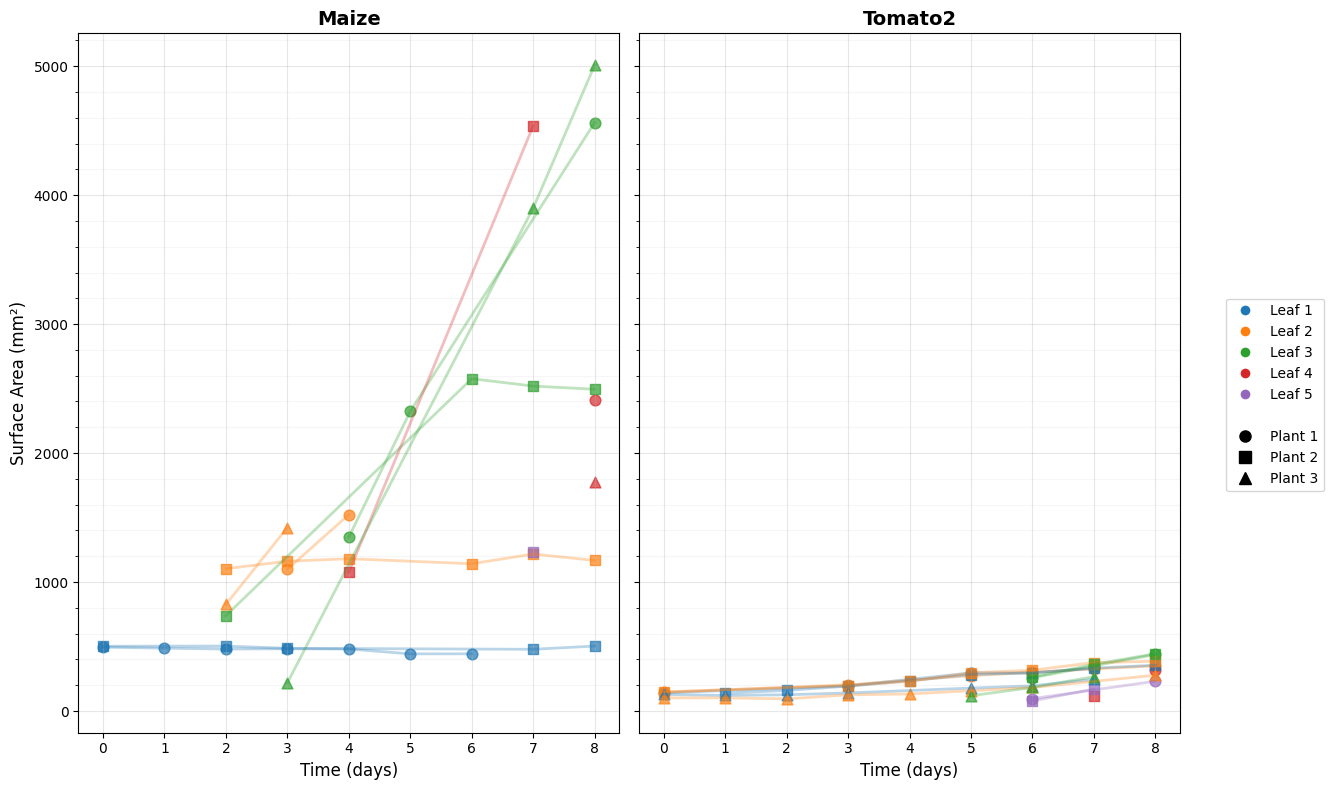


Summary by crop and plant:

MAIZE:
  Plant 1: 13 measurements, Area range: 443.3 - 4562.6 mm²
    Leaf 1: 7 measurements, Area: 443.3 - 495.3 mm²
    Leaf 2: 2 measurements, Area: 1099.3 - 1522.9 mm²
    Leaf 3: 3 measurements, Area: 1348.9 - 4562.6 mm²
    Leaf 4: 1 measurements, Area: 2415.1 - 2415.1 mm²
  Plant 2: 18 measurements, Area range: 478.7 - 4537.7 mm²
    Leaf 1: 5 measurements, Area: 478.7 - 503.9 mm²
    Leaf 2: 6 measurements, Area: 1103.8 - 1217.2 mm²
    Leaf 3: 4 measurements, Area: 739.7 - 2576.7 mm²
    Leaf 4: 2 measurements, Area: 1077.5 - 4537.7 mm²
    Leaf 5: 1 measurements, Area: 1230.4 - 1230.4 mm²
  Plant 3: 6 measurements, Area range: 218.7 - 5007.9 mm²
    Leaf 2: 2 measurements, Area: 826.7 - 1423.0 mm²
    Leaf 3: 3 measurements, Area: 218.7 - 5007.9 mm²
    Leaf 4: 1 measurements, Area: 1779.3 - 1779.3 mm²

TOMATO2:
  Plant 1: 17 measurements, Area range: 96.3 - 438.6 mm²
    Leaf 1: 5 measurements, Area: 140.2 - 331.2 mm²
    Leaf 2: 6 measurements, 

In [5]:
# Check if we have data to plot
if len(plot_df) == 0:
    print("No data available for plotting. Please check the data extraction step above.")
else:
    # Get unique crops and set up side-by-side subplots
    crops = sorted(plot_df['crop'].unique())
    n_crops = len(crops)
    
    fig, axes = plt.subplots(1, n_crops, figsize=(6 * n_crops, 8), sharey=True)
    if n_crops == 1:
        axes = [axes]  # Make it a list for consistency
    
    # Define colors for each leaf number (use enough colors for all possible leaf numbers)
    colors = plt.cm.tab10(np.arange(10))
    markers = ['o', 's', '^', 'D', 'v']  # Different markers for different plants
    
    for crop_idx, crop in enumerate(crops):
        ax = axes[crop_idx]
        crop_data = plot_df[plot_df['crop'] == crop]
        
        # Get unique plants and leaf numbers for this crop
        plants = sorted(crop_data['plant'].unique())
        leaf_numbers = sorted(crop_data['leaf'].unique())
        
        print(f"\n{crop.upper()} - Plants: {plants}, Leaf numbers: {leaf_numbers}")
        
        # Plot each combination of plant and leaf number
        for i, plant in enumerate(plants):
            for leaf_num in leaf_numbers:
                # Filter data for this plant and leaf number
                data_subset = crop_data[(crop_data['plant'] == plant) & (crop_data['leaf'] == leaf_num)]
                
                if len(data_subset) > 0:
                    ax.scatter(data_subset['day'], data_subset['surface_area_mm2'], 
                             color=colors[leaf_num-1], marker=markers[i % len(markers)], s=60,
                             alpha=0.7)
                    
                    # Connect points for the same leaf within a plant with lines
                    if len(data_subset) > 1:
                        sorted_data = data_subset.sort_values('day')
                        ax.plot(sorted_data['day'], sorted_data['surface_area_mm2'], 
                               color=colors[leaf_num-1], linestyle='-', alpha=0.3, linewidth=2)
        
        # Formatting for each subplot
        ax.set_xlabel('Time (days)', fontsize=12)
        if crop_idx == 0:
            ax.set_ylabel('Surface Area (mm²)', fontsize=12)
        
        ax.set_title(f'{crop.capitalize()}', fontsize=14, fontweight='bold')
        
        # Add minor ticks and grid
        from matplotlib.ticker import AutoMinorLocator
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.grid(True, alpha=0.3)
        ax.grid(True, which='minor', alpha=0.1)
    
    # Create unified legend for all subplots
    # Collect all unique leaf numbers and plants across all crops
    all_leaf_numbers = sorted(plot_df['leaf'].unique())
    all_plants = sorted(plot_df['plant'].unique())
    
    legend_elements = []
    
    # Add leaf number colors to legend
    for leaf_num in all_leaf_numbers:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor=colors[leaf_num-1], markersize=8,
                                     label=f'Leaf {leaf_num}'))
    
    # Add separator
    legend_elements.append(Line2D([0], [0], marker='', color='w', label=''))
    
    # Add plant markers to legend
    for i, plant in enumerate(all_plants):
        legend_elements.append(Line2D([0], [0], marker=markers[i % len(markers)], color='k', 
                                     markersize=8, linestyle='None',
                                     label=f'Plant {plant}'))
    
    # Place legend to the right of all subplots
    fig.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.5), loc='center left')
    
    plt.tight_layout()
    
    # Save the figure
    Path("../figures").mkdir(parents=True, exist_ok=True)
    plt.savefig("../figures/trackplant3D_gt_leaves_area_timeseries_by_species.pdf", dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics by crop and plant
    print("\nSummary by crop and plant:")
    for crop in crops:
        crop_data = plot_df[plot_df['crop'] == crop]
        print(f"\n{crop.upper()}:")
        for plant in sorted(crop_data['plant'].unique()):
            plant_data = crop_data[crop_data['plant'] == plant]
            print(f"  Plant {plant}: {len(plant_data)} measurements, "
                  f"Area range: {plant_data['surface_area_mm2'].min():.1f} - {plant_data['surface_area_mm2'].max():.1f} mm²")
            
            # Print leaf-level stats for this plant
            for leaf_num in sorted(plant_data['leaf'].unique()):
                leaf_data = plant_data[plant_data['leaf'] == leaf_num]
                print(f"    Leaf {leaf_num}: {len(leaf_data)} measurements, "
                      f"Area: {leaf_data['surface_area_mm2'].min():.1f} - {leaf_data['surface_area_mm2'].max():.1f} mm²")